In [1]:
# Esame 654AA - a.a. 2025/2026
# Studenti: Leonardo Celati, Samuele Taviano
# Matricole: 660185, ?

<h1>Wine dataset SVC</h1>
<p>Analysis performed with a classifier.</p>
<hr/>

In [2]:
import importlib

import numpy as np
from sklearn.svm import SVR
from sklearn.svm import SVC
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold, cross_val_score, cross_val_predict
import wine_common as wine
import svm_common as sc
from scipy.stats import loguniform

importlib.reload(wine)

<module 'wine_common' from '/Users/leonardo/workspace/library/source/it.unipi.654AA/collaudo/wine_common.py'>

<h2>Walktrough</h2>
<hr/>

<h3>Notebook parameters</h3>

In [3]:
# We only test SVR in this Notebook
# Note: for full control on dataset the pipe
# only include the regression
pipe_default = Pipeline(steps=[
    ("svm", SVC())
])

# CV params
n_split = 5
default_random_state = 42

# Of all parameters 'shuffle' is relevant because the TR set is small
# We also prefer StratifiedKFold as it preserves class balance during folding (optimal in small dataset)
default_cv = StratifiedKFold(n_splits=n_split, shuffle=True, random_state=default_random_state)

# Subset is derived from data analysis
# and feature selection, more for learning purpose
# than for real needs as the numner of features is small
subset_features_1 = [
    'alcohol',
    'volatile acidity',
    'sulphates',
    'citric acid',
    'total sulfur dioxide'
]


<h3>Data Loading</h3>
<p>
Key points about data:
<ul>
<li>Data returned by <code>split_and_prepare_dataset</code> are normalized with MinMaxScaler</li>
<li>Altough not necessary due to the relatively small dimension of the samples, feature selection has been applied for academic purpose (see wine_data_introspection)</li>
<li>Altough outliers are present, they have not been removed in order to see how data reflect in model choice and hyperparameters tuning
</ul>
</p>

In [4]:
importlib.reload(wine)
df_train, df_test = wine.stratified_split(type='red', seed=default_random_state)
X_tr_full, y_tr, X_ts, y_ts = wine.split_and_prepare_dataset(df_train, df_test)
X_tr = X_tr_full[subset_features_1]
X_ts = X_ts[subset_features_1]
wine.dataset_introspection(df_train, df_test)

,Property,Training,Test
0,Number of samples,1280,319
1,Number of features,11,11
2,Class values,"[3, 4, 5, 6, 7, 8]","[3, 4, 5, 6, 7, 8]"
3,Class balance,"quality 3 = 9, quality 4 = 44, quality 5 = 551...","quality 3 = 1, quality 4 = 9, quality 5 = 130,..."


<h3>Model Selection</h3>
<p>Finding the best model with GridSearchCV.</p>

<h4>Step 1</h4>
<p>First randomized search to identify a coarse grained set of parameters.</p>

In [5]:
random_param = {
    "svm__C": loguniform(1e-3, 1e3), # it means: [0.001,0.01,0.1,1,10,100,1000]
    "svm__gamma": loguniform(1e-4, 1e1), # # it means: [0.0001, 0.001,0.01,0.1,1,10]
    "svm__kernel": ["rbf", "poly", "linear", "sigmoid"],
    "svm__degree": [2, 3, 4]
}

random_search = RandomizedSearchCV(
    estimator=pipe_default,
    param_distributions=random_param,
    n_iter=50, # search will evaluate 50 combination of the random_param
    scoring="balanced_accuracy", # wine dataset is declared to be unbalanced
    cv=default_cv,
    random_state=default_random_state
)

random_search.fit(X_tr, y_tr)
best_random_params = random_search.best_params_
sc.grid_introspection(random_search)

Total model explored: 50
Best params: {'svm__C': np.float64(5.132347525675519), 'svm__degree': 4, 'svm__gamma': np.float64(8.24431219090507), 'svm__kernel': 'rbf'}
Best CV accuracy: 0.28838477174939403
Best model: Pipeline(steps=[('svm',
                 SVC(C=np.float64(5.132347525675519), degree=4,
                     gamma=np.float64(8.24431219090507)))])
Total support vectors: 1020
Support vectors per class: [  9  44 374 434 146  13]


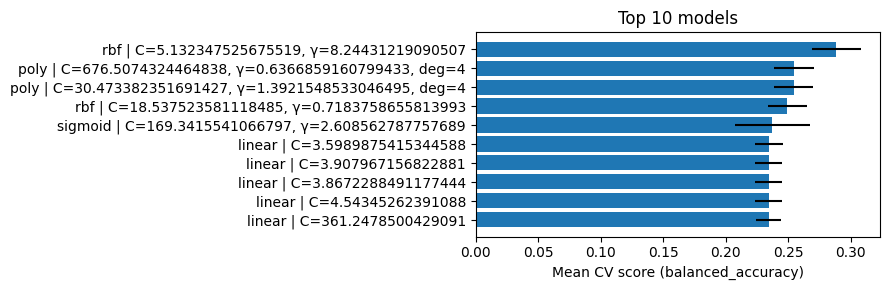

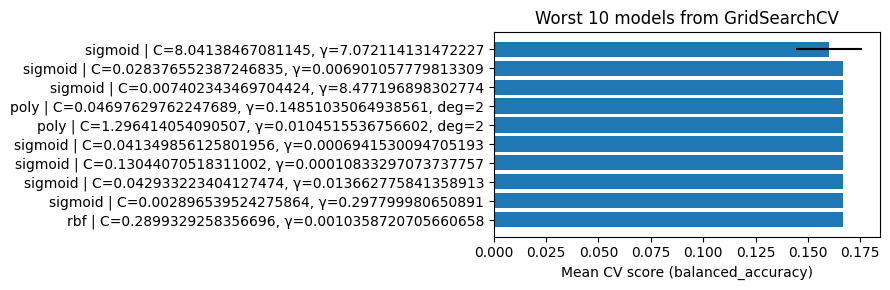

In [6]:
sc.plot_results_svc(random_search.cv_results_)

<h4>Step 2</h4>
<p>Refined grid search around best params obtained with randomized search.</p>

In [7]:

def local_log_grid(x: float, factors=(0.25, 0.5, 1.0, 2.0, 4.0)) -> list[float]:
    """
    Helper function dealing with C Logarithmic exploration.
    i.e. given x=5 it returns a surrounding set of C [1.25, 2.5, <-- (x=5.0) -->, 10.0, 20.0]
    :param x: the parameter to enlarge greater than 0
    :param factors: the default neighbours
    :return: a list of floats conform to the factors
    """
    return sorted({float(x)*f for f in factors if float(x)*f > 0})


# Compose param grid search based on parameters resulting from previous random search
best_kernel = best_random_params["svm__kernel"]
grid_param = {
    "svm__kernel": [best_kernel],
    "svm__C": local_log_grid(best_random_params["svm__C"])
}

# Custom param depending on kernel choice
if best_kernel in ("rbf", "poly"):
    grid_param["svm__gamma"] = local_log_grid(best_random_params["svm__gamma"])

if best_kernel == "poly":
    d = int(best_random_params.get("svm__degree", 3))
    grid_param["svm__degree"] = sorted({max(2, d - 1), d, d + 1})

# Perform a grid search
refine_search = GridSearchCV(
    estimator = pipe_default,
    param_grid = grid_param,
    cv = default_cv,
    scoring = random_search.scoring
)

# # Fit TR features and labels into grid
refine_search.fit(X_tr, y_tr)
best_model = refine_search.best_estimator_

In [8]:
sc.grid_introspection(refine_search)

Total model explored: 25
Best params: {'svm__C': 20.529390102702077, 'svm__gamma': 32.97724876362028, 'svm__kernel': 'rbf'}
Best CV accuracy: 0.30881680040343645
Best model: Pipeline(steps=[('svm', SVC(C=20.529390102702077, gamma=32.97724876362028))])
Total support vectors: 1011
Support vectors per class: [  9  44 380 422 143  13]


<h3>Model Assesment</h3>
<hr/>

<h4>Predict</h4>
<p>Performing the predictions on the <b>training set</b>.</p>

In [9]:
cv_predictions = cross_val_predict(
    best_model,
    X_tr, y_tr,
    cv=default_cv
)

<h5>Metric</h5>
<p>The SVR predictive performance represented by these metrics:
<ul>
	<li>MAE (Mean Absolute Error): average absolute prediction error</li>
	<li>MSE (Mean Squared Error): average squared error, sensitive to outliers</li>
	<li>RMSE (Root Mean Squared Error): square root of MSE, same scale as target</li>
	<li>R² (Coefficient of Determination): proportion of variance explained by the model</li>
</ul>

</p>
$$
\text{MAE} = \frac{1}{n}\sum_{i=1}^{n} |y_i - \hat{y}_i| \qquad
\text{MSE} = \frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2 \qquad
\text{RMSE} = \sqrt{\text{MSE}} \qquad
R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}
$$


In [10]:
mae = mean_absolute_error(y_tr, cv_predictions)
mse = mean_squared_error(y_tr, cv_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_tr, cv_predictions)

print(f"MAE  = {mae:.3f}")
print(f"MSE  = {mse:.3f}")
print(f"RMSE = {rmse:.3f}")
print(f"R²   = {r2:.3f}")

MAE  = 0.475
MSE  = 0.658
RMSE = 0.811
R²   = -0.009


<h5>Predicted vs True quality</h5>
<p>The plot showing the prediciton vs true labels on the training dataset.</p>

In [11]:
print(classification_report(y_tr, cv_predictions, zero_division=0))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         9
           4       0.10      0.07      0.08        44
           5       0.67      0.72      0.69       551
           6       0.60      0.61      0.60       506
           7       0.52      0.46      0.49       157
           8       0.00      0.00      0.00        13

    accuracy                           0.61      1280
   macro avg       0.32      0.31      0.31      1280
weighted avg       0.59      0.61      0.60      1280



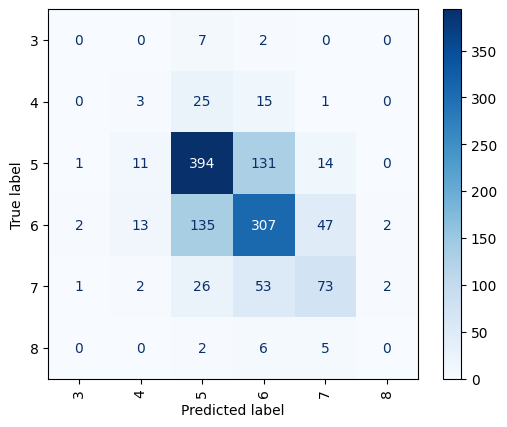

In [12]:
ConfusionMatrixDisplay.from_predictions(y_tr, cv_predictions, xticks_rotation='vertical', cmap='Blues');

<h5>Learning Curves</h5>
<p>This plot shows the evolution of training and cross-validation errors as the training set size increases. The learning curve helps assess whether the model suffers from underfitting or overfitting and whether performance is limited by model capacity or by intrinsic noise in the data.</p>

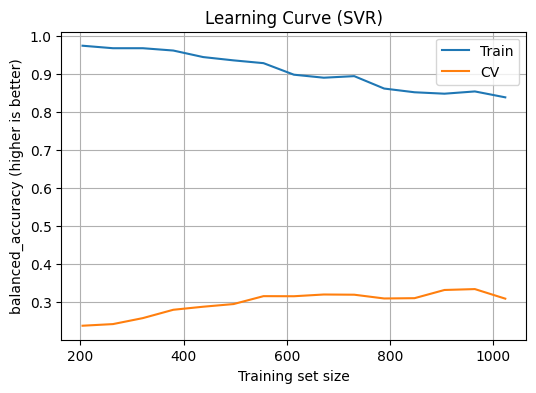

In [13]:
sc.plot_learning_curve_svr(best_model, X_tr, y_tr, default_cv, scoring=random_search.scoring)

<h3>Test predictions</h3>
<hr/>

<h4>Predict</h4>
<p>Performing the predictions on the <b>training set</b>.</p>

In [14]:
test_predictions = best_model.predict(X_ts)

<h5>Predicted vs True quality</h5>
<p>This scatter plot compares the true quality values with the corresponding predictions produced by the model. The diagonal line represents perfect predictions, while the dispersion of points around it highlights prediction errors, bias, and the presence of intrinsic noise in the data.</p>

In [15]:
print(classification_report(y_ts, test_predictions, zero_division=0))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.06      0.11      0.08         9
           5       0.62      0.45      0.52       130
           6       0.48      0.59      0.53       132
           7       0.22      0.21      0.22        42
           8       0.00      0.00      0.00         5

    accuracy                           0.46       319
   macro avg       0.23      0.23      0.22       319
weighted avg       0.48      0.46      0.46       319



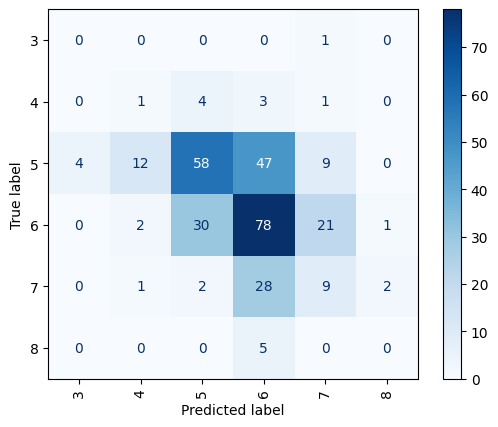

In [16]:
ConfusionMatrixDisplay.from_predictions(y_ts, test_predictions, xticks_rotation='vertical', cmap='Blues');